# Bài tập thực hành tuần 8

> Họ và tên: Nguyễn Vạn Phúc Huy <br>
> MSSV: 23110163 <br>
> Lớp: 23TTH (Sáng thứ 6)

In [2]:
import math
import matplotlib.pyplot as plt
import numpy as np
import time
import random
import heapq
import sys
from time import perf_counter
from math import log2

### Bài tập:
**Câu hỏi**:

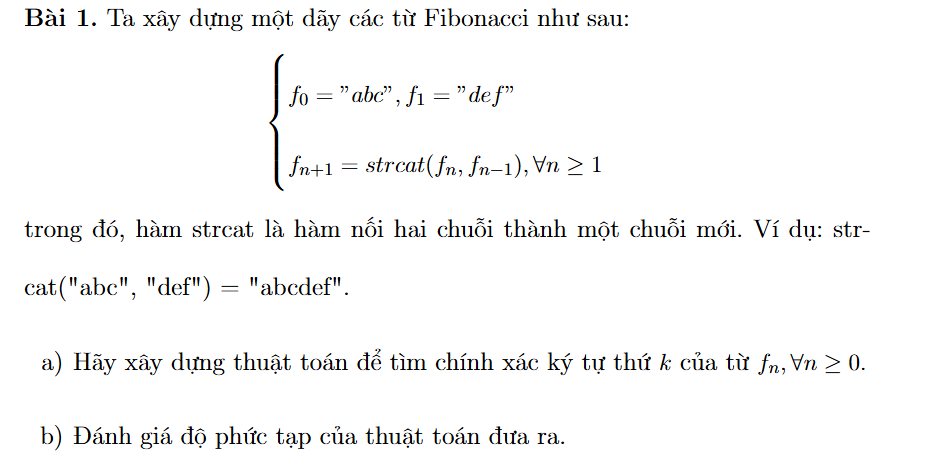

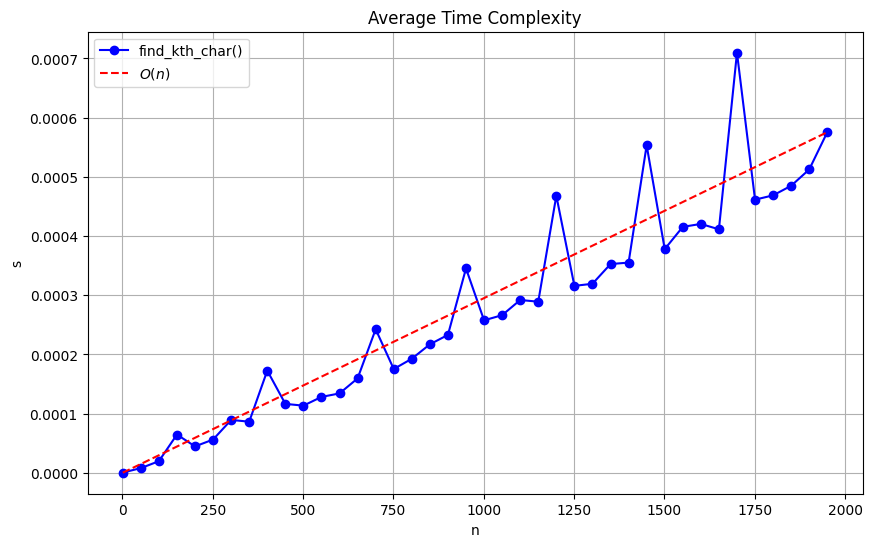

In [12]:
import time
import matplotlib.pyplot as plt

def find_k_char(n, k):
    L = [0] * (n + 1)
    L[0] = 3
    if n > 0:
        L[1] = 3
        for i in range(2, n + 1):
            L[i] = L[i-1] + L[i-2]

    def search(n_curr, k_curr):
        if n_curr == 0:
            return "abc"[k_curr - 1] 
        if n_curr == 1:
            return "def"[k_curr - 1]
            
        len_first_half = L[n_curr - 1]
        
        if k_curr <= len_first_half:
            return search(n_curr - 1, k_curr)
        else:
            return search(n_curr - 2, k_curr - len_first_half)

    return search(n, k)

n_values = list(range(1, 2001, 50)) # Từ 1 đến 2000 với bước 50 để tránh thời gian quá lâu
avg_times = []
num_trials = 100 

for n in n_values:
    total_time = 0
    k_test = 2 
    
    for _ in range(num_trials):
        start_time = time.perf_counter()
        find_k_char(n, k_test)
        end_time = time.perf_counter()
        
        total_time += (end_time - start_time)
        
    avg_times.append(total_time / num_trials)

C = avg_times[-1] / n_values[-1]
bigO_line = [C * n for n in n_values]

# Vẽ đồ thị
plt.figure(figsize=(10, 6))
plt.plot(n_values, avg_times, marker='o', color='blue', label='find_kth_char()')
plt.plot(n_values, bigO_line, linestyle='--', color='red', label=r'$O(n)$')

plt.title('Average Time Complexity')
plt.xlabel('n')
plt.ylabel('s')
plt.legend()
plt.grid(True)
plt.show()

```py
import time
import matplotlib.pyplot as plt

def find_k_char(n, k):
    L = [0] * (n + 1)
    L[0] = 3
    if n > 0:
        L[1] = 3
        for i in range(2, n + 1):
            L[i] = L[i-1] + L[i-2]

    def search(n_curr, k_curr):
        if n_curr == 0:
            return "abc"[k_curr - 1] 
        if n_curr == 1:
            return "def"[k_curr - 1]
            
        len_first_half = L[n_curr - 1]
        
        if k_curr <= len_first_half:
            return search(n_curr - 1, k_curr)
        else:
            return search(n_curr - 2, k_curr - len_first_half)

    return search(n, k)

n_values = list(range(1, 2001, 50)) # Từ 1 đến 2000 với bước 50 để tránh thời gian quá lâu
avg_times = []
num_trials = 100 

for n in n_values:
    total_time = 0
    k_test = 2 
    
    for _ in range(num_trials):
        start_time = time.perf_counter()
        find_k_char(n, k_test)
        end_time = time.perf_counter()
        
        total_time += (end_time - start_time)
        
    avg_times.append(total_time / num_trials)

C = avg_times[-1] / n_values[-1]
bigO_line = [C * n for n in n_values]

# Vẽ đồ thị
plt.figure(figsize=(10, 6))
plt.plot(n_values, avg_times, marker='o', color='blue', label='find_kth_char()')
plt.plot(n_values, bigO_line, linestyle='--', color='red', label=r'$O(n)$')

plt.title('Average Time Complexity')
plt.xlabel('n')
plt.ylabel('s')
plt.legend()
plt.grid(True)
plt.show()
```

Hàm `find_k_char(n, k)` sử dụng thuật toán chia để trị để tìm ký tự thứ k trong chuỗi Fibonacci thứ n. Thuật toán này hoạt động như sau:
1. **Khởi tạo mảng độ dài**: Đầu tiên, chúng ta khởi tạo một mảng `L` để lưu trữ độ dài của các chuỗi Fibonacci từ `f_0` đến `f_n`. Độ dài của chuỗi Fibonacci thứ n được tính bằng công thức: `L[n] = L[n-1] + L[n-2]`, với `L[0] = 3` và `L[1] = 3`.
2. **Đệ quy tìm kiếm**: Sau khi có mảng độ dài, chúng ta sử dụng một hàm đệ quy `search(n_curr, k_curr)` để tìm ký tự thứ k trong chuỗi Fibonacci thứ n. Hàm này hoạt động như sau:
   - Nếu `n_curr` là 0, trả về ký tự thứ `k_curr` trong chuỗi `f_0` ("abc").
   - Nếu `n_curr` là 1, trả về ký tự thứ `k_curr` trong chuỗi `f_1` ("def").
    - Nếu `n_curr` lớn hơn 1, chúng ta kiểm tra xem `k_curr` có nằm trong nửa đầu của chuỗi Fibonacci thứ `n_curr` hay không. Nếu có, chúng ta tiếp tục tìm kiếm trong chuỗi Fibonacci thứ `n_curr - 1`. Nếu không, chúng ta tìm kiếm trong chuỗi Fibonacci thứ `n_curr - 2`, đồng thời điều chỉnh lại giá trị của `k_curr` bằng cách trừ đi độ dài của nửa đầu.
3. **Trả về kết quả**: Kết quả cuối cùng sẽ là ký tự thứ k trong chuỗi Fibonacci thứ n.


Chương trình chính thực hiện các bước sau:
1. Định nghĩa dải giá trị `n` từ 1 đến 2000 với bước nhảy là 50 để tránh thời gian thực thi quá lâu.
2. Tạo một danh sách `avg_times` để lưu trữ thời gian trung bình cho mỗi giá trị của `n`.
3. Sử dụng một vòng lặp để lặp qua các giá trị của `n` và thực hiện 100 lần thử nghiệm cho mỗi `n` để đo thời gian thực thi của hàm `find_k_char(n, k)`.
4. Tính thời gian trung bình cho mỗi `n` và lưu trữ vào `avg_times`.
5. Tính hằng số `C` để vẽ đường tiệm cận lý thuyết O(n) và vẽ đồ thị so sánh thời gian thực thi với đường O(n). 

Kết quả từ đồ thị cho thấy thời gian trung bình của hàm `find_k_char` tăng tuyến tính với `n`, và nó rất giống với đường O(n), chứng tỏ rằng độ phức tạp thời gian của thuật toán này là O(n).


